# DQN for 2048 — enhanced architecture (dueling + residual MLP + n-step)

This version keeps the thin OpenSpiel wrapper and legal-action masking from the strong baseline, but upgrades the learner in three substantive ways:

1. **Dueling Q-network**: separate value and advantage heads for more stable action-value estimation.
2. **Residual MLP backbone**: deeper but still lightweight, easier to optimize than a large CNN on a 4x4 board.
3. **n-step returns (default: 3-step)**: propagate useful reward information faster than pure 1-step TD.

It also keeps:
- **Double DQN**
- **Huber loss**
- **fixed validation / test seeds**
- **checkpoint + resume**


In [1]:
# Colab / notebook setup
!python -V
!pip -q install --upgrade pip
!pip -q install open-spiel torch matplotlib imageio tqdm

Python 3.12.12
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.1 MB/s eta 0:00:00


In [2]:
import os
import json
import random
import re
from collections import deque, namedtuple

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import pyspiel

print("PyTorch version:", torch.__version__)
print("OpenSpiel version:", pyspiel.__version__ if hasattr(pyspiel, "__version__") else "unknown")

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("CUDA available:", torch.cuda.is_available())
print("MPS available:", hasattr(torch.backends, "mps") and torch.backends.mps.is_available())
print("Device:", DEVICE)

PyTorch version: 2.10.0+cu128
OpenSpiel version: 1.6.12
CUDA available: True
MPS available: False
Device: cuda


## Inspect OpenSpiel 2048

In [3]:
game = pyspiel.load_game("2048")
state = game.new_initial_state()

game_type = game.get_type()
short_name = game_type.short_name if hasattr(game_type, "short_name") else "2048"

print("Registered game:", short_name)
print("Num distinct actions:", game.num_distinct_actions())
print("Observation tensor shape:", game.observation_tensor_shape())
print("Observation tensor size:", game.observation_tensor_size())
print("Max chance outcomes:", game.max_chance_outcomes())
print("Max game length:", game.max_game_length())
print("Min / Max utility:", game.min_utility(), game.max_utility())
print()
print("Initial state is chance node:", state.is_chance_node())
print("Initial state string:")
print(state)

Registered game: 2048
Num distinct actions: 4
Observation tensor shape: [4, 4]
Observation tensor size: 16
Max chance outcomes: 33
Max game length: 8192
Min / Max utility: 0.0 20480.0

Initial state is chance node: True
Initial state string:
    0    0    0    0
    0    0    0    0
    0    0    0    0
    0    0    0    0



## Helpers for observation, chance nodes, and board parsing

In [4]:
def extract_obs(state, player_id=0):
    """Return a flat float32 observation vector for the player."""
    for fn_name, args in [
        ("observation_tensor", (player_id,)),
        ("observation_tensor", tuple()),
        ("information_state_tensor", (player_id,)),
        ("information_state_tensor", tuple()),
    ]:
        fn = getattr(state, fn_name, None)
        if fn is None:
            continue
        try:
            obs = fn(*args)
            obs = np.asarray(obs, dtype=np.float32).reshape(-1)
            return obs
        except TypeError:
            pass
    raise RuntimeError("Could not extract an observation tensor from state.")


def legal_actions(state, player_id=0):
    try:
        return list(state.legal_actions(player_id))
    except TypeError:
        return list(state.legal_actions())


def sample_chance_action(state, rng):
    outcomes = state.chance_outcomes()
    actions, probs = zip(*outcomes)
    idx = rng.choice(len(actions), p=np.asarray(probs, dtype=np.float64))
    return actions[idx]


def auto_resolve_chance_nodes(state, rng):
    while state.is_chance_node() and not state.is_terminal():
        a = sample_chance_action(state, rng)
        state.apply_action(a)
    return state


def state_return(state, player_id=0):
    vals = state.returns()
    return float(vals[player_id]) if len(vals) > player_id else 0.0


def state_reward(state, player_id=0):
    vals = state.rewards()
    return float(vals[player_id]) if len(vals) > player_id else 0.0


def parse_board_numbers(state):
    """Best-effort parser for showing the board as a 4x4 integer array."""
    txt = str(state)
    nums = [int(x) for x in re.findall(r"\d+", txt)]
    if len(nums) >= 16:
        nums = nums[-16:]
        return np.array(nums, dtype=np.int64).reshape(4, 4)
    return None


test_state = game.new_initial_state()
auto_resolve_chance_nodes(test_state, np.random.default_rng(0))
print("Observation shape after resolving initial chance:", extract_obs(test_state).shape)
print("Legal actions:", legal_actions(test_state))
print("Board (best effort):")
print(parse_board_numbers(test_state))
print()
print(test_state)

Observation shape after resolving initial chance: (16,)
Legal actions: [0, 1, 2, 3]
Board (best effort):
[[0 0 0 0]
 [2 0 0 0]
 [0 0 2 0]
 [0 0 0 0]]

    0    0    0    0
    2    0    0    0
    0    0    2    0
    0    0    0    0



## Lightweight environment wrapper

In [5]:
class OpenSpiel2048Env:
    def __init__(self, seed=42):
        self.game = pyspiel.load_game("2048")
        self.player_id = 0
        self.num_actions = self.game.num_distinct_actions()
        self.obs_dim = self.game.observation_tensor_size()
        self.rng = np.random.default_rng(seed)
        self.state = None

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.state = self.game.new_initial_state()
        auto_resolve_chance_nodes(self.state, self.rng)
        return extract_obs(self.state, self.player_id)

    def step(self, action):
        if self.state is None:
            raise RuntimeError("Call reset() before step().")
        if self.state.is_terminal():
            raise RuntimeError("Episode already ended. Call reset().")

        legal = legal_actions(self.state, self.player_id)
        if action not in legal:
            raise ValueError(f"Illegal action {action}. Legal actions: {legal}")

        prev_return = state_return(self.state, self.player_id)

        self.state.apply_action(int(action))
        auto_resolve_chance_nodes(self.state, self.rng)

        done = self.state.is_terminal()
        next_obs = (
            extract_obs(self.state, self.player_id)
            if not done else np.zeros(self.obs_dim, dtype=np.float32)
        )
        new_return = state_return(self.state, self.player_id)

        reward = new_return - prev_return
        info = {
            "legal_actions": legal_actions(self.state, self.player_id) if not done else [],
            "state_return": new_return,
            "state_reward_raw": state_reward(self.state, self.player_id),
            "board": parse_board_numbers(self.state),
            "state_text": str(self.state),
        }
        return next_obs, float(reward), done, info

    def legal_actions(self):
        if self.state is None or self.state.is_terminal():
            return []
        return legal_actions(self.state, self.player_id)

    def render(self):
        if self.state is None:
            print("<env not reset>")
        else:
            print(self.state)

## Model, replay buffer, and n-step transition collector

Compared with the simple-spirit notebook, this cell introduces a stronger but still compact learner:

- **Dueling Q-network** with a **residual MLP** backbone
- **n-step return collector** to speed up credit assignment
- same replay-buffer API and same legal-action masking logic


In [6]:
Transition = namedtuple(
    "Transition",
    ["obs", "action", "reward", "next_obs", "done", "discount", "legal_mask", "next_legal_mask"],
)

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def __len__(self):
        return len(self.buffer)

    def add(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))


class NStepTransitionCollector:
    def __init__(self, n_step, gamma):
        self.n_step = n_step
        self.gamma = gamma
        self.queue = deque()

    def reset(self):
        self.queue.clear()

    def __len__(self):
        return len(self.queue)

    def _build_transition_from_front(self):
        obs, action, _, _, _, legal_mask, _ = self.queue[0]

        total_reward = 0.0
        discount = 1.0
        next_obs = self.queue[-1][3]
        done = self.queue[-1][4]
        next_legal_mask = self.queue[-1][6]

        for _, _, reward_i, next_obs_i, done_i, _, next_legal_mask_i in self.queue:
            total_reward += discount * float(reward_i)
            next_obs = next_obs_i
            done = done_i
            next_legal_mask = next_legal_mask_i
            if done_i:
                return Transition(
                    obs, action, float(total_reward), next_obs, True, 0.0,
                    legal_mask, next_legal_mask
                )
            discount *= self.gamma

        return Transition(
            obs, action, float(total_reward), next_obs, done, float(discount),
            legal_mask, next_legal_mask
        )

    def add(self, obs, action, reward, next_obs, done, legal_mask, next_legal_mask):
        """Returns a list of ready-to-store n-step transitions (0 or more)."""
        self.queue.append((obs, action, reward, next_obs, done, legal_mask, next_legal_mask))
        ready = []

        if len(self.queue) >= self.n_step:
            ready.append(self._build_transition_from_front())
            self.queue.popleft()

        if done:
            while self.queue:
                ready.append(self._build_transition_from_front())
                self.queue.popleft()

        return ready


def make_legal_mask(num_actions, legal_actions_list):
    mask = np.zeros(num_actions, dtype=np.float32)
    if len(legal_actions_list) > 0:
        mask[legal_actions_list] = 1.0
    return mask


class ResidualMLPBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.dropout = nn.Dropout(dropout)
        self.act = nn.ReLU()

    def forward(self, x):
        h = self.fc1(x)
        h = self.norm1(h)
        h = self.act(h)
        h = self.dropout(h)
        h = self.fc2(h)
        h = self.norm2(h)
        return self.act(x + h)


class DuelingResidualQNetwork(nn.Module):
    def __init__(self, obs_dim, num_actions, hidden_dim=256, num_blocks=2, dropout=0.0):
        super().__init__()
        self.input = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
        )
        self.blocks = nn.Sequential(*[
            ResidualMLPBlock(hidden_dim, dropout=dropout) for _ in range(num_blocks)
        ])
        self.value_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.adv_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_actions),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)
        nn.init.orthogonal_(self.value_head[-1].weight, gain=1.0)
        nn.init.orthogonal_(self.adv_head[-1].weight, gain=0.01)

    def forward(self, x):
        h = self.input(x)
        h = self.blocks(h)
        value = self.value_head(h)
        adv = self.adv_head(h)
        q = value + adv - adv.mean(dim=1, keepdim=True)
        return q


@torch.no_grad()
def masked_greedy_action(q_net, obs, legal_actions_list, num_actions, epsilon=0.0, device=DEVICE):
    if random.random() < epsilon:
        return random.choice(legal_actions_list)

    obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
    q = q_net(obs_t).squeeze(0)

    legal_mask = torch.zeros(num_actions, dtype=torch.bool, device=device)
    legal_mask[legal_actions_list] = True

    q_masked = q.masked_fill(~legal_mask, -1e9)
    action = int(torch.argmax(q_masked).item())
    return action


## Hyperparameters

This notebook now uses a stronger learner than the simple-spirit version, so the configuration below is tuned for:
- **faster credit assignment** via n-step returns
- **stable but not timid learning**
- **fair model selection** using fixed validation/test seeds


In [7]:
# Reproducibility
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Training hyperparameters
NUM_EPISODES = 12_000
BUFFER_SIZE = 150_000
BATCH_SIZE = 128
GAMMA = 0.99
N_STEP = 3
LR = 5e-4
TARGET_SYNC_EVERY = 500
LEARN_START = 2_000
LEARN_EVERY = 4
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY_STEPS = 60_000
MAX_STEPS_PER_EPISODE = 5_000
GRAD_CLIP = 10.0

# Model hyperparameters
HIDDEN_DIM = 256
NUM_RES_BLOCKS = 2
DROPOUT = 0.0

# Evaluation protocol
EVAL_EVERY = 100
VAL_SEEDS = list(range(10_000, 10_050))    # fixed validation seeds
TEST_SEEDS = list(range(20_000, 20_100))   # fixed test seeds

# Checkpointing / resume
CHECKPOINT_DIR = "checkpoints_2048_dueling_nstep"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
LATEST_CKPT_PATH = os.path.join(CHECKPOINT_DIR, "latest_resume.pt")
BEST_CKPT_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pt")
SAVE_EVERY = 250
RESUME = False   # set True to continue training from LATEST_CKPT_PATH

train_env = OpenSpiel2048Env(seed=SEED)
obs_dim = train_env.obs_dim
num_actions = train_env.num_actions

q_net = DuelingResidualQNetwork(
    obs_dim, num_actions,
    hidden_dim=HIDDEN_DIM,
    num_blocks=NUM_RES_BLOCKS,
    dropout=DROPOUT,
).to(DEVICE)
target_net = DuelingResidualQNetwork(
    obs_dim, num_actions,
    hidden_dim=HIDDEN_DIM,
    num_blocks=NUM_RES_BLOCKS,
    dropout=DROPOUT,
).to(DEVICE)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=LR)
replay = ReplayBuffer(BUFFER_SIZE)
n_step_collector = NStepTransitionCollector(n_step=N_STEP, gamma=GAMMA)

print("obs_dim =", obs_dim)
print("num_actions =", num_actions)
print("device =", DEVICE)
print("architecture = DuelingResidualQNetwork")
print("n_step =", N_STEP)


obs_dim = 16
num_actions = 4
device = cuda


## Training helpers

The update is still **Double DQN + Huber loss**, but now the replay entries can carry an **n-step discount** instead of a fixed 1-step gamma.


In [8]:
def epsilon_by_step(step):
    frac = min(1.0, step / EPS_DECAY_STEPS)
    return EPS_START + frac * (EPS_END - EPS_START)


def dqn_update(batch):
    obs = torch.tensor(np.asarray(batch.obs), dtype=torch.float32, device=DEVICE)
    actions = torch.tensor(batch.action, dtype=torch.int64, device=DEVICE).unsqueeze(1)
    rewards = torch.tensor(batch.reward, dtype=torch.float32, device=DEVICE)
    next_obs = torch.tensor(np.asarray(batch.next_obs), dtype=torch.float32, device=DEVICE)
    dones = torch.tensor(batch.done, dtype=torch.float32, device=DEVICE)
    discounts = torch.tensor(batch.discount, dtype=torch.float32, device=DEVICE)

    next_legal_mask = torch.tensor(np.asarray(batch.next_legal_mask), dtype=torch.bool, device=DEVICE)

    q_values = q_net(obs)
    q_sa = q_values.gather(1, actions).squeeze(1)

    with torch.no_grad():
        next_q_online = q_net(next_obs)
        next_q_online = next_q_online.masked_fill(~next_legal_mask, -1e9)
        next_actions = torch.argmax(next_q_online, dim=1, keepdim=True)

        next_q_target = target_net(next_obs).gather(1, next_actions).squeeze(1)
        next_q_target = torch.where(dones > 0.5, torch.zeros_like(next_q_target), next_q_target)

        target = rewards + discounts * next_q_target

    loss = F.smooth_l1_loss(q_sa, target)

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(q_net.parameters(), GRAD_CLIP)
    optimizer.step()

    return float(loss.item())


@torch.no_grad()
def evaluate_policy(model, seeds, max_steps=MAX_STEPS_PER_EPISODE):
    returns = []
    lengths = []
    max_tiles = []

    for seed in seeds:
        env = OpenSpiel2048Env(seed=seed)
        obs = env.reset(seed=seed)
        done = False
        ep_return = 0.0
        ep_len = 0
        last_board = None

        while not done and ep_len < max_steps:
            legal = env.legal_actions()
            action = masked_greedy_action(model, obs, legal, env.num_actions, epsilon=0.0, device=DEVICE)
            obs, reward, done, info = env.step(action)
            ep_return += reward
            ep_len += 1
            if info.get("board") is not None:
                last_board = info["board"]

        returns.append(float(ep_return))
        lengths.append(int(ep_len))
        max_tiles.append(int(last_board.max()) if last_board is not None else 0)

    returns = np.asarray(returns, dtype=np.float32)
    lengths = np.asarray(lengths, dtype=np.float32)
    max_tiles = np.asarray(max_tiles, dtype=np.int64)

    return {
        "mean_return": float(np.mean(returns)),
        "std_return": float(np.std(returns)),
        "mean_length": float(np.mean(lengths)),
        "mean_max_tile": float(np.mean(max_tiles)),
        "returns": returns,
        "lengths": lengths,
        "max_tiles": max_tiles,
    }


def summarize_tiles(max_tiles):
    max_tiles = np.asarray(max_tiles)
    summary = {}
    for level in [64, 128, 256, 512, 1024, 2048]:
        summary[level] = float(np.mean(max_tiles >= level))
    return summary


## Checkpoint / resume helpers

The resume checkpoint now stores not only model / optimizer / replay, but also the **n-step collector queue**, so long runs can continue more faithfully.


In [9]:
def torch_load_compat(path, map_location=DEVICE):
    # PyTorch 2.6 changed the default torch.load behavior; this notebook saves its own checkpoints,
    # so weights_only=False is the intended behavior here.
    return torch.load(path, map_location=map_location, weights_only=False)


def save_resume_checkpoint(path, episode, global_step, best_eval_mean, best_state_dict,
                           episode_returns, episode_lengths, loss_history, val_history):
    ckpt = {
        "episode": episode,
        "global_step": global_step,
        "model_state_dict": q_net.state_dict(),
        "target_state_dict": target_net.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "replay_buffer": list(replay.buffer),
        "n_step_queue": list(n_step_collector.queue),
        "best_eval_mean": best_eval_mean,
        "best_state_dict": best_state_dict,
        "episode_returns": episode_returns,
        "episode_lengths": episode_lengths,
        "loss_history": loss_history,
        "val_history": val_history,
        "config": {
            "SEED": SEED,
            "NUM_EPISODES": NUM_EPISODES,
            "BUFFER_SIZE": BUFFER_SIZE,
            "BATCH_SIZE": BATCH_SIZE,
            "GAMMA": GAMMA,
            "N_STEP": N_STEP,
            "LR": LR,
            "TARGET_SYNC_EVERY": TARGET_SYNC_EVERY,
            "LEARN_START": LEARN_START,
            "LEARN_EVERY": LEARN_EVERY,
            "EPS_START": EPS_START,
            "EPS_END": EPS_END,
            "EPS_DECAY_STEPS": EPS_DECAY_STEPS,
            "MAX_STEPS_PER_EPISODE": MAX_STEPS_PER_EPISODE,
            "GRAD_CLIP": GRAD_CLIP,
            "HIDDEN_DIM": HIDDEN_DIM,
            "NUM_RES_BLOCKS": NUM_RES_BLOCKS,
            "DROPOUT": DROPOUT,
        },
        "rng_state": {
            "python_random": random.getstate(),
            "numpy_random": np.random.get_state(),
            "torch_random": torch.get_rng_state(),
            "torch_cuda_random": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        },
    }
    torch.save(ckpt, path)


def load_resume_checkpoint(path):
    ckpt = torch_load_compat(path, map_location=DEVICE)

    q_net.load_state_dict(ckpt["model_state_dict"])
    target_net.load_state_dict(ckpt["target_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])

    for state in optimizer.state.values():
        for k, v in state.items():
            if torch.is_tensor(v):
                state[k] = v.to(DEVICE)

    replay.buffer.clear()
    replay.buffer.extend(ckpt["replay_buffer"])
    n_step_collector.queue.clear()
    n_step_collector.queue.extend(ckpt.get("n_step_queue", []))

    if "rng_state" in ckpt:
        random.setstate(ckpt["rng_state"]["python_random"])
        np.random.set_state(ckpt["rng_state"]["numpy_random"])
        torch.set_rng_state(ckpt["rng_state"]["torch_random"])
        if torch.cuda.is_available() and ckpt["rng_state"]["torch_cuda_random"] is not None:
            torch.cuda.set_rng_state_all(ckpt["rng_state"]["torch_cuda_random"])

    return ckpt


## Train

This loop is still simple, but now each environment step first goes through the **n-step collector** before being inserted into replay.


In [10]:
episode_returns = []
episode_lengths = []
loss_history = []
val_history = []

global_step = 0
best_eval_mean = -float("inf")
best_state_dict = None
start_episode = 1

if RESUME and os.path.exists(LATEST_CKPT_PATH):
    ckpt = load_resume_checkpoint(LATEST_CKPT_PATH)
    episode_returns = ckpt["episode_returns"]
    episode_lengths = ckpt["episode_lengths"]
    loss_history = ckpt["loss_history"]
    val_history = ckpt["val_history"]
    global_step = ckpt["global_step"]
    best_eval_mean = ckpt["best_eval_mean"]
    best_state_dict = ckpt["best_state_dict"]
    start_episode = ckpt["episode"] + 1
    print(f"Resumed from {LATEST_CKPT_PATH} | start_episode={start_episode} | global_step={global_step} | replay={len(replay)} | nstep_queue={len(n_step_collector)}")
else:
    print("Starting fresh training.")

for episode in tqdm(range(start_episode, NUM_EPISODES + 1), desc="Training"):
    obs = train_env.reset(seed=SEED + episode)
    done = False
    ep_return = 0.0
    ep_len = 0
    n_step_collector.reset()

    while not done and ep_len < MAX_STEPS_PER_EPISODE:
        eps = epsilon_by_step(global_step)
        legal = train_env.legal_actions()
        legal_mask = make_legal_mask(num_actions, legal)

        action = masked_greedy_action(
            q_net=q_net,
            obs=obs,
            legal_actions_list=legal,
            num_actions=num_actions,
            epsilon=eps,
            device=DEVICE,
        )

        next_obs, reward, done, info = train_env.step(action)
        next_legal = info["legal_actions"] if not done else []
        next_legal_mask = make_legal_mask(num_actions, next_legal)

        ready_transitions = n_step_collector.add(
            obs, action, reward, next_obs, done, legal_mask, next_legal_mask
        )
        for tr in ready_transitions:
            replay.add(*tr)

        obs = next_obs
        ep_return += reward
        ep_len += 1
        global_step += 1

        if len(replay) >= max(LEARN_START, BATCH_SIZE) and global_step % LEARN_EVERY == 0:
            batch = replay.sample(BATCH_SIZE)
            loss = dqn_update(batch)
            loss_history.append(loss)

        if global_step % TARGET_SYNC_EVERY == 0:
            target_net.load_state_dict(q_net.state_dict())

    episode_returns.append(ep_return)
    episode_lengths.append(ep_len)

    if episode % EVAL_EVERY == 0:
        metrics = evaluate_policy(q_net, VAL_SEEDS)
        tile_summary = summarize_tiles(metrics["max_tiles"])
        val_history.append({
            "episode": episode,
            "mean_return": metrics["mean_return"],
            "std_return": metrics["std_return"],
            "mean_length": metrics["mean_length"],
            "mean_max_tile": metrics["mean_max_tile"],
            "tile_summary": tile_summary,
        })

        print(
            f"[Val] ep={episode:6d} | mean={metrics['mean_return']:.1f} | "
            f"std={metrics['std_return']:.1f} | len={metrics['mean_length']:.1f} | "
            f"mean_max_tile={metrics['mean_max_tile']:.1f} | "
            f">=256={100*tile_summary[256]:.1f}% | >=512={100*tile_summary[512]:.1f}%"
        )

        if metrics["mean_return"] > best_eval_mean:
            best_eval_mean = metrics["mean_return"]
            best_state_dict = {k: v.detach().cpu().clone() for k, v in q_net.state_dict().items()}
            torch.save(
                {
                    "model_state_dict": best_state_dict,
                    "episode": episode,
                    "best_val_mean_return": best_eval_mean,
                    "val_metrics": {
                        "mean_return": metrics["mean_return"],
                        "std_return": metrics["std_return"],
                        "mean_length": metrics["mean_length"],
                        "mean_max_tile": metrics["mean_max_tile"],
                        "tile_summary": tile_summary,
                    },
                    "architecture": "DuelingResidualQNetwork",
                    "n_step": N_STEP,
                },
                BEST_CKPT_PATH,
            )
            print(f"  -> new best model saved to {BEST_CKPT_PATH}")

    if episode % SAVE_EVERY == 0:
        save_resume_checkpoint(
            LATEST_CKPT_PATH, episode, global_step, best_eval_mean, best_state_dict,
            episode_returns, episode_lengths, loss_history, val_history
        )

save_resume_checkpoint(
    LATEST_CKPT_PATH, episode, global_step, best_eval_mean, best_state_dict,
    episode_returns, episode_lengths, loss_history, val_history
)

print("Training complete.")
print("Best validation mean return:", best_eval_mean)


Starting fresh training.


Training:   0%|          | 0/5000 [00:00<?, ?it/s]

[Val] ep=    50 | mean=1606.2 | std=1060.9 | len=157.9 | mean_max_tile=131.2 | >=256=25.0% | >=512=0.0%
  -> new best model saved to checkpoints_2048_simple_spirit/best_model.pt
[Val] ep=   100 | mean=2158.0 | std=876.8 | len=197.1 | mean_max_tile=182.4 | >=256=50.0% | >=512=0.0%
  -> new best model saved to checkpoints_2048_simple_spirit/best_model.pt
[Val] ep=   150 | mean=2328.8 | std=1559.8 | len=206.8 | mean_max_tile=193.6 | >=256=40.0% | >=512=10.0%
  -> new best model saved to checkpoints_2048_simple_spirit/best_model.pt
[Val] ep=   200 | mean=2350.4 | std=887.0 | len=214.2 | mean_max_tile=185.6 | >=256=45.0% | >=512=0.0%
  -> new best model saved to checkpoints_2048_simple_spirit/best_model.pt
[Val] ep=   250 | mean=1998.0 | std=923.4 | len=180.2 | mean_max_tile=192.0 | >=256=50.0% | >=512=5.0%
[Val] ep=   300 | mean=1958.4 | std=870.8 | len=186.9 | mean_max_tile=153.6 | >=256=30.0% | >=512=0.0%
[Val] ep=   350 | mean=2051.4 | std=1265.8 | len=187.1 | mean_max_tile=172.8 | >=25

## Training curves

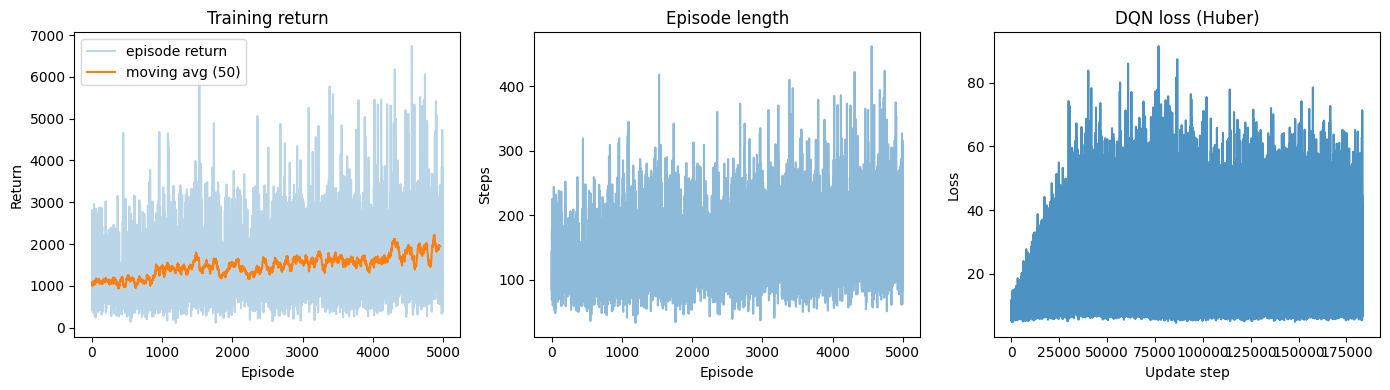

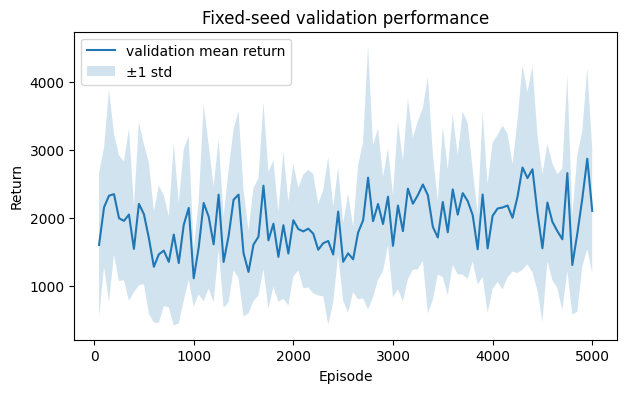

In [11]:
def moving_average(x, w=50):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode="valid")

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(episode_returns, alpha=0.30, label="episode return")
ma = moving_average(episode_returns, 50)
plt.plot(range(len(ma)), ma, label="moving avg (50)")
plt.title("Training return")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(episode_lengths, alpha=0.5)
plt.title("Episode length")
plt.xlabel("Episode")
plt.ylabel("Steps")

plt.subplot(1, 3, 3)
plt.plot(loss_history, alpha=0.8)
plt.title("DQN loss (Huber)")
plt.xlabel("Update step")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

if val_history:
    val_eps = [x["episode"] for x in val_history]
    val_means = [x["mean_return"] for x in val_history]
    val_stds = [x["std_return"] for x in val_history]

    plt.figure(figsize=(7, 4))
    plt.plot(val_eps, val_means, label="validation mean return")
    plt.fill_between(
        val_eps,
        np.asarray(val_means) - np.asarray(val_stds),
        np.asarray(val_means) + np.asarray(val_stds),
        alpha=0.2,
        label="±1 std",
    )
    plt.title("Fixed-seed validation performance")
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.legend()
    plt.show()

## Load the best validation checkpoint and evaluate on fixed test seeds

This is the main score you should trust for reporting: the model selected on **fixed validation seeds**, then evaluated on a **separate fixed test set**.


In [12]:
if os.path.exists(BEST_CKPT_PATH):
    best_ckpt = torch_load_compat(BEST_CKPT_PATH, map_location=DEVICE)
    q_net.load_state_dict(best_ckpt["model_state_dict"])
    target_net.load_state_dict(best_ckpt["model_state_dict"])
    print("Loaded best validation checkpoint from:", BEST_CKPT_PATH)
    print("Best validation mean return:", best_ckpt["best_val_mean_return"])
    if "val_metrics" in best_ckpt:
        print("Validation summary:", best_ckpt["val_metrics"])
else:
    print("Best checkpoint not found; using current q_net weights.")

test_metrics = evaluate_policy(q_net, TEST_SEEDS)
test_tile_summary = summarize_tiles(test_metrics["max_tiles"])

print(f"Test mean return: {test_metrics['mean_return']:.1f}")
print(f"Test std return: {test_metrics['std_return']:.1f}")
print(f"Test mean length: {test_metrics['mean_length']:.1f}")
print(f"Test mean max tile: {test_metrics['mean_max_tile']:.1f}")
for lvl in [64, 128, 256, 512, 1024, 2048]:
    print(f"P(max_tile >= {lvl:4d}): {100*test_tile_summary[lvl]:5.1f}%")


Loaded best validation checkpoint from: checkpoints_2048_simple_spirit/best_model.pt
Best validation mean return: 2870.60009765625
Test mean return: 2149.3
Test std return: 1349.4
Test mean length: 194.0
Test mean max tile: 179.8
P(max_tile >=   64):  98.0%
P(max_tile >=  128):  74.0%
P(max_tile >=  256):  38.0%
P(max_tile >=  512):   8.0%
P(max_tile >= 1024):   0.0%
P(max_tile >= 2048):   0.0%


## One greedy rollout (qualitative only)

This rollout is useful for seeing a concrete game, but it should not be treated as the main benchmark. Trust the fixed-seed validation/test metrics above more than any single rollout.


In [13]:
eval_seed = TEST_SEEDS[0]
eval_env = OpenSpiel2048Env(seed=eval_seed)
obs = eval_env.reset(seed=eval_seed)
done = False
greedy_return = 0.0
rollout = []

while not done and len(rollout) < MAX_STEPS_PER_EPISODE:
    legal = eval_env.legal_actions()
    action = masked_greedy_action(q_net, obs, legal, num_actions, epsilon=0.0, device=DEVICE)
    next_obs, reward, done, info = eval_env.step(action)
    rollout.append({
        "action": action,
        "reward": reward,
        "legal_actions": legal,
        "board": info["board"],
        "state_text": info["state_text"],
    })
    obs = next_obs
    greedy_return += reward

print("Greedy evaluation return:", greedy_return)
print("Rollout length:", len(rollout))
if rollout and rollout[-1]["board"] is not None:
    print("Max tile reached:", int(np.max(rollout[-1]["board"])))
    print()
    print(rollout[-1]["board"])
print()
eval_env.render()

Greedy evaluation return: 3236.0
Rollout length: 272
Max tile reached: 256

[[  4  32  64   2]
 [ 32 256  16   4]
 [  8 128   8  16]
 [ 16   8   4   2]]

    4   32   64    2
   32  256   16    4
    8  128    8   16
   16    8    4    2



In [14]:
# Show a few last boards from the greedy rollout
n_show = min(5, len(rollout))
for i, step_info in enumerate(rollout[-n_show:], start=len(rollout)-n_show+1):
    print("=" * 60)
    print(f"Step {i} | action={step_info['action']} | reward={step_info['reward']:.1f}")
    if step_info["board"] is not None:
        print(step_info["board"])
    print(step_info["state_text"])

Step 268 | action=0 | reward=16.0
[[  4  32  64   2]
 [ 32 256  16   4]
 [  8 128   2  16]
 [ 16   8   2   2]]
    4   32   64    2
   32  256   16    4
    8  128    2   16
   16    8    2    2

Step 269 | action=0 | reward=4.0
[[  4  32  64   2]
 [ 32 256  16   4]
 [  8 128   4  16]
 [ 16   8   2   2]]
    4   32   64    2
   32  256   16    4
    8  128    4   16
   16    8    2    2

Step 270 | action=3 | reward=4.0
[[  4  32  64   2]
 [ 32 256  16   4]
 [  8 128   4  16]
 [ 16   8   4   2]]
    4   32   64    2
   32  256   16    4
    8  128    4   16
   16    8    4    2

Step 271 | action=0 | reward=8.0
[[  4  32  64   2]
 [ 32 256  16   4]
 [  8 128   8  16]
 [ 16   8   2   2]]
    4   32   64    2
   32  256   16    4
    8  128    8   16
   16    8    2    2

Step 272 | action=3 | reward=4.0
[[  4  32  64   2]
 [ 32 256  16   4]
 [  8 128   8  16]
 [ 16   8   4   2]]
    4   32   64    2
   32  256   16    4
    8  128    8   16
   16    8    4    2



## Save a compact final artifact

The final artifact includes the stronger architecture metadata so it is easier to document in the report.


In [15]:
final_artifact_path = "dqn_openspiel_2048_dueling_residual_nstep.pt"
torch.save(
    {
        "model_state_dict": q_net.state_dict(),
        "target_state_dict": target_net.state_dict(),
        "architecture": "DuelingResidualQNetwork",
        "obs_dim": obs_dim,
        "num_actions": num_actions,
        "hidden_dim": HIDDEN_DIM,
        "num_res_blocks": NUM_RES_BLOCKS,
        "dropout": DROPOUT,
        "n_step": N_STEP,
        "gamma": GAMMA,
        "device": str(DEVICE),
        "episode_returns": episode_returns,
        "episode_lengths": episode_lengths,
        "loss_history": loss_history,
        "val_history": val_history,
        "test_metrics": test_metrics,
        "test_tile_summary": test_tile_summary,
    },
    final_artifact_path,
)
print("Saved compact model artifact to:", final_artifact_path)


Saved compact model artifact to: dqn_openspiel_2048_simple_spirit.pt
